In [32]:
import pandas as pd

df = pd.read_csv('input_data/deliveries.csv')

df.sample(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
6559,336009,2,Chennai Super Kings,Delhi Daredevils,10,6,MS Dhoni,PJ Sangwan,JA Morkel,1,0,1,NaN,0,NaN,NaN,NaN
216400,1304081,1,Gujarat Titans,Kolkata Knight Riders,13,6,DA Miller,SP Narine,HH Pandya,0,0,0,NaN,0,NaN,NaN,NaN
32106,419126,2,Rajasthan Royals,Deccan Chargers,4,3,NV Ojha,RG Sharma,MJ Lumb,6,0,6,NaN,0,NaN,NaN,NaN
240597,1359535,2,Kolkata Knight Riders,Chennai Super Kings,13,6,RK Singh,RA Jadeja,N Rana,0,0,0,NaN,0,NaN,NaN,NaN
115808,829765,1,Chennai Super Kings,Kolkata Knight Riders,12,6,DJ Bravo,PP Chawla,F du Plessis,0,0,0,NaN,1,DJ Bravo,caught,SA Yadav
63440,548326,2,Rajasthan Royals,Deccan Chargers,3,2,R Dravid,DT Christian,AM Rahane,4,0,4,NaN,0,NaN,NaN,NaN
242689,1359544,1,Royal Challengers Bangalore,Gujarat Titans,9,6,V Kohli,Noor Ahmad,MG Bracewell,1,0,1,NaN,0,NaN,NaN,NaN
200360,1254085,2,Sunrisers Hyderabad,Rajasthan Royals,8,5,V Shankar,C Sakariya,KS Williamson,0,0,0,NaN,0,NaN,NaN,NaN
80703,598015,2,Chennai Super Kings,Pune Warriors,17,5,CH Morris,AB Dinda,JA Morkel,0,0,0,NaN,0,NaN,NaN,NaN
144768,1082626,1,Delhi Daredevils,Kings XI Punjab,10,4,K Rabada,AR Patel,CJ Anderson,1,0,1,NaN,0,NaN,NaN,NaN


In [33]:
match_ids = df.match_id.unique()

matches = {elem : pd.DataFrame() for elem in match_ids}

for key in matches.keys():
    matches[key] = df[:][df.match_id == key]

all_players = {batter: [] for batter in list(df.batter.unique())+list(df.non_striker.unique())}

print(matches)

{np.int64(335982):      match_id  inning                 batting_team  \
0      335982       1        Kolkata Knight Riders   
1      335982       1        Kolkata Knight Riders   
2      335982       1        Kolkata Knight Riders   
3      335982       1        Kolkata Knight Riders   
4      335982       1        Kolkata Knight Riders   
..        ...     ...                          ...   
220    335982       2  Royal Challengers Bangalore   
221    335982       2  Royal Challengers Bangalore   
222    335982       2  Royal Challengers Bangalore   
223    335982       2  Royal Challengers Bangalore   
224    335982       2  Royal Challengers Bangalore   

                    bowling_team  over  ball       batter     bowler  \
0    Royal Challengers Bangalore     0     1   SC Ganguly    P Kumar   
1    Royal Challengers Bangalore     0     2  BB McCullum    P Kumar   
2    Royal Challengers Bangalore     0     3  BB McCullum    P Kumar   
3    Royal Challengers Bangalore     0     4

In [34]:
def get_batsman(match):
    innings = match[match.inning == 1], match[match.inning == 2]
    players = {batter: {'runs': 0, 'balls': 0, 'innings_runs':0, 'batting_position': None, 'runs_come_in':None, 'overs_come_in': None, 'match_id':None} for batter in list(match.batter.unique())+list(match.non_striker.unique())}
    for inn in innings:
        total_runs = 0
        batsmanIn = []
        for _, ball in inn.iterrows():
            # Wide and no balls don't go to the batman's balls faced
            for bat in [ball.batter, ball.non_striker]:
                if bat not in batsmanIn:
                    batsmanIn.append(bat)
                    players[bat]['batting_position'] = len(batsmanIn)
                    players[bat]['runs_come_in'] = total_runs
                    players[bat]['overs_come_in'] = ball.over + ball.ball/6
                    players[bat]['match_id'] = ball.match_id
            if ball.extras_type == 'wides' or ball.extras_type == 'noballs':
                continue
            players[ball.batter]['runs'] += ball.batsman_runs
            players[ball.batter]['balls'] += 1

            total_runs += ball.batsman_runs
        for player in inn.batter.unique():
            players[player]['innings_runs'] = total_runs
        
    return players


get_batsman(matches[335982])

{'SC Ganguly': {'runs': 10,
  'balls': 12,
  'innings_runs': 205,
  'batting_position': 1,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 335982},
 'BB McCullum': {'runs': 158,
  'balls': 73,
  'innings_runs': 205,
  'batting_position': 2,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 335982},
 'RT Ponting': {'runs': 20,
  'balls': 20,
  'innings_runs': 205,
  'batting_position': 3,
  'runs_come_in': 51,
  'overs_come_in': 5.5,
  'match_id': 335982},
 'DJ Hussey': {'runs': 12,
  'balls': 12,
  'innings_runs': 205,
  'batting_position': 4,
  'runs_come_in': 98,
  'overs_come_in': 12.333333333333334,
  'match_id': 335982},
 'Mohammad Hafeez': {'runs': 5,
  'balls': 3,
  'innings_runs': 205,
  'batting_position': 5,
  'runs_come_in': 155,
  'overs_come_in': 17.333333333333332,
  'match_id': 335982},
 'R Dravid': {'runs': 2,
  'balls': 3,
  'innings_runs': 63,
  'batting_position': 1,
  'runs_come_in': 0,
  'overs_come_in': 0.1666666

In [35]:
for match in matches.values():
    scores = get_batsman(match)
    for player, inn in scores.items():
        all_players[player].append(inn)

In [36]:
all_players

{'SC Ganguly': [{'runs': 10,
   'balls': 12,
   'innings_runs': 205,
   'batting_position': 1,
   'runs_come_in': 0,
   'overs_come_in': 0.16666666666666666,
   'match_id': 335982},
  {'runs': 14,
   'balls': 29,
   'innings_runs': 84,
   'batting_position': 4,
   'runs_come_in': 12,
   'overs_come_in': 2.3333333333333335,
   'match_id': 335986},
  {'runs': 12,
   'balls': 19,
   'innings_runs': 139,
   'batting_position': 1,
   'runs_come_in': 0,
   'overs_come_in': 0.16666666666666666,
   'match_id': 335993},
  {'runs': 4,
   'balls': 2,
   'innings_runs': 124,
   'batting_position': 2,
   'runs_come_in': 0,
   'overs_come_in': 0.16666666666666666,
   'match_id': 335997},
  {'runs': 51,
   'balls': 39,
   'innings_runs': 139,
   'batting_position': 2,
   'runs_come_in': 0,
   'overs_come_in': 0.16666666666666666,
   'match_id': 336000},
  {'runs': 5,
   'balls': 7,
   'innings_runs': 162,
   'batting_position': 2,
   'runs_come_in': 0,
   'overs_come_in': 0.16666666666666666,
   'mat

In [39]:
every_bat = [a for b in all_players.values() for a in b]

every_bat_runs = [a['runs'] for a in every_bat]
every_bat_balls = [a['balls'] for a in every_bat]
every_bat_innings_runs = [a['innings_runs'] for a in every_bat]
every_batting_position = [a['batting_position'] for a in every_bat]
every_runs_come_in = [a['runs_come_in'] for a in every_bat]
every_overs_come_in = [a['overs_come_in'] for a in every_bat]
every_match_id = [a['match_id'] for a in every_bat]

pd.DataFrame([every_bat_runs, every_bat_balls, every_bat_innings_runs, every_batting_position, every_runs_come_in, every_overs_come_in, every_match_id], index=['runs', 'balls', 'innings_runs', 'batting_position', 'runs_come_in', 'overs_come_in', 'match_id']).T.to_csv('batsman_runs.csv', index=False)

[{'runs': 10,
  'balls': 12,
  'innings_runs': 205,
  'batting_position': 1,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 335982},
 {'runs': 14,
  'balls': 29,
  'innings_runs': 84,
  'batting_position': 4,
  'runs_come_in': 12,
  'overs_come_in': 2.3333333333333335,
  'match_id': 335986},
 {'runs': 12,
  'balls': 19,
  'innings_runs': 139,
  'batting_position': 1,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 335993},
 {'runs': 4,
  'balls': 2,
  'innings_runs': 124,
  'batting_position': 2,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 335997},
 {'runs': 51,
  'balls': 39,
  'innings_runs': 139,
  'batting_position': 2,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 336000},
 {'runs': 5,
  'balls': 7,
  'innings_runs': 162,
  'batting_position': 2,
  'runs_come_in': 0,
  'overs_come_in': 0.16666666666666666,
  'match_id': 336003},
 {'runs': 20,
  'balls': 22,
  'innings

Balls Faced,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
Runs Scored,,,,,,,,,,,,,,,,,,,,,
0,668,1532,680,370,158,80,22,28,16,6,...,0,0,0,0,0,0,0,0,0,0
1,0,592,680,420,258,192,74,64,30,18,...,0,0,0,0,0,0,0,0,0,0
2,0,50,290,374,296,220,132,80,50,44,...,0,0,0,0,0,0,0,0,0,0
3,0,10,64,142,202,208,132,138,74,58,...,0,0,0,0,0,0,0,0,0,0
4,0,58,136,146,200,172,158,132,70,66,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
168,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
169,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


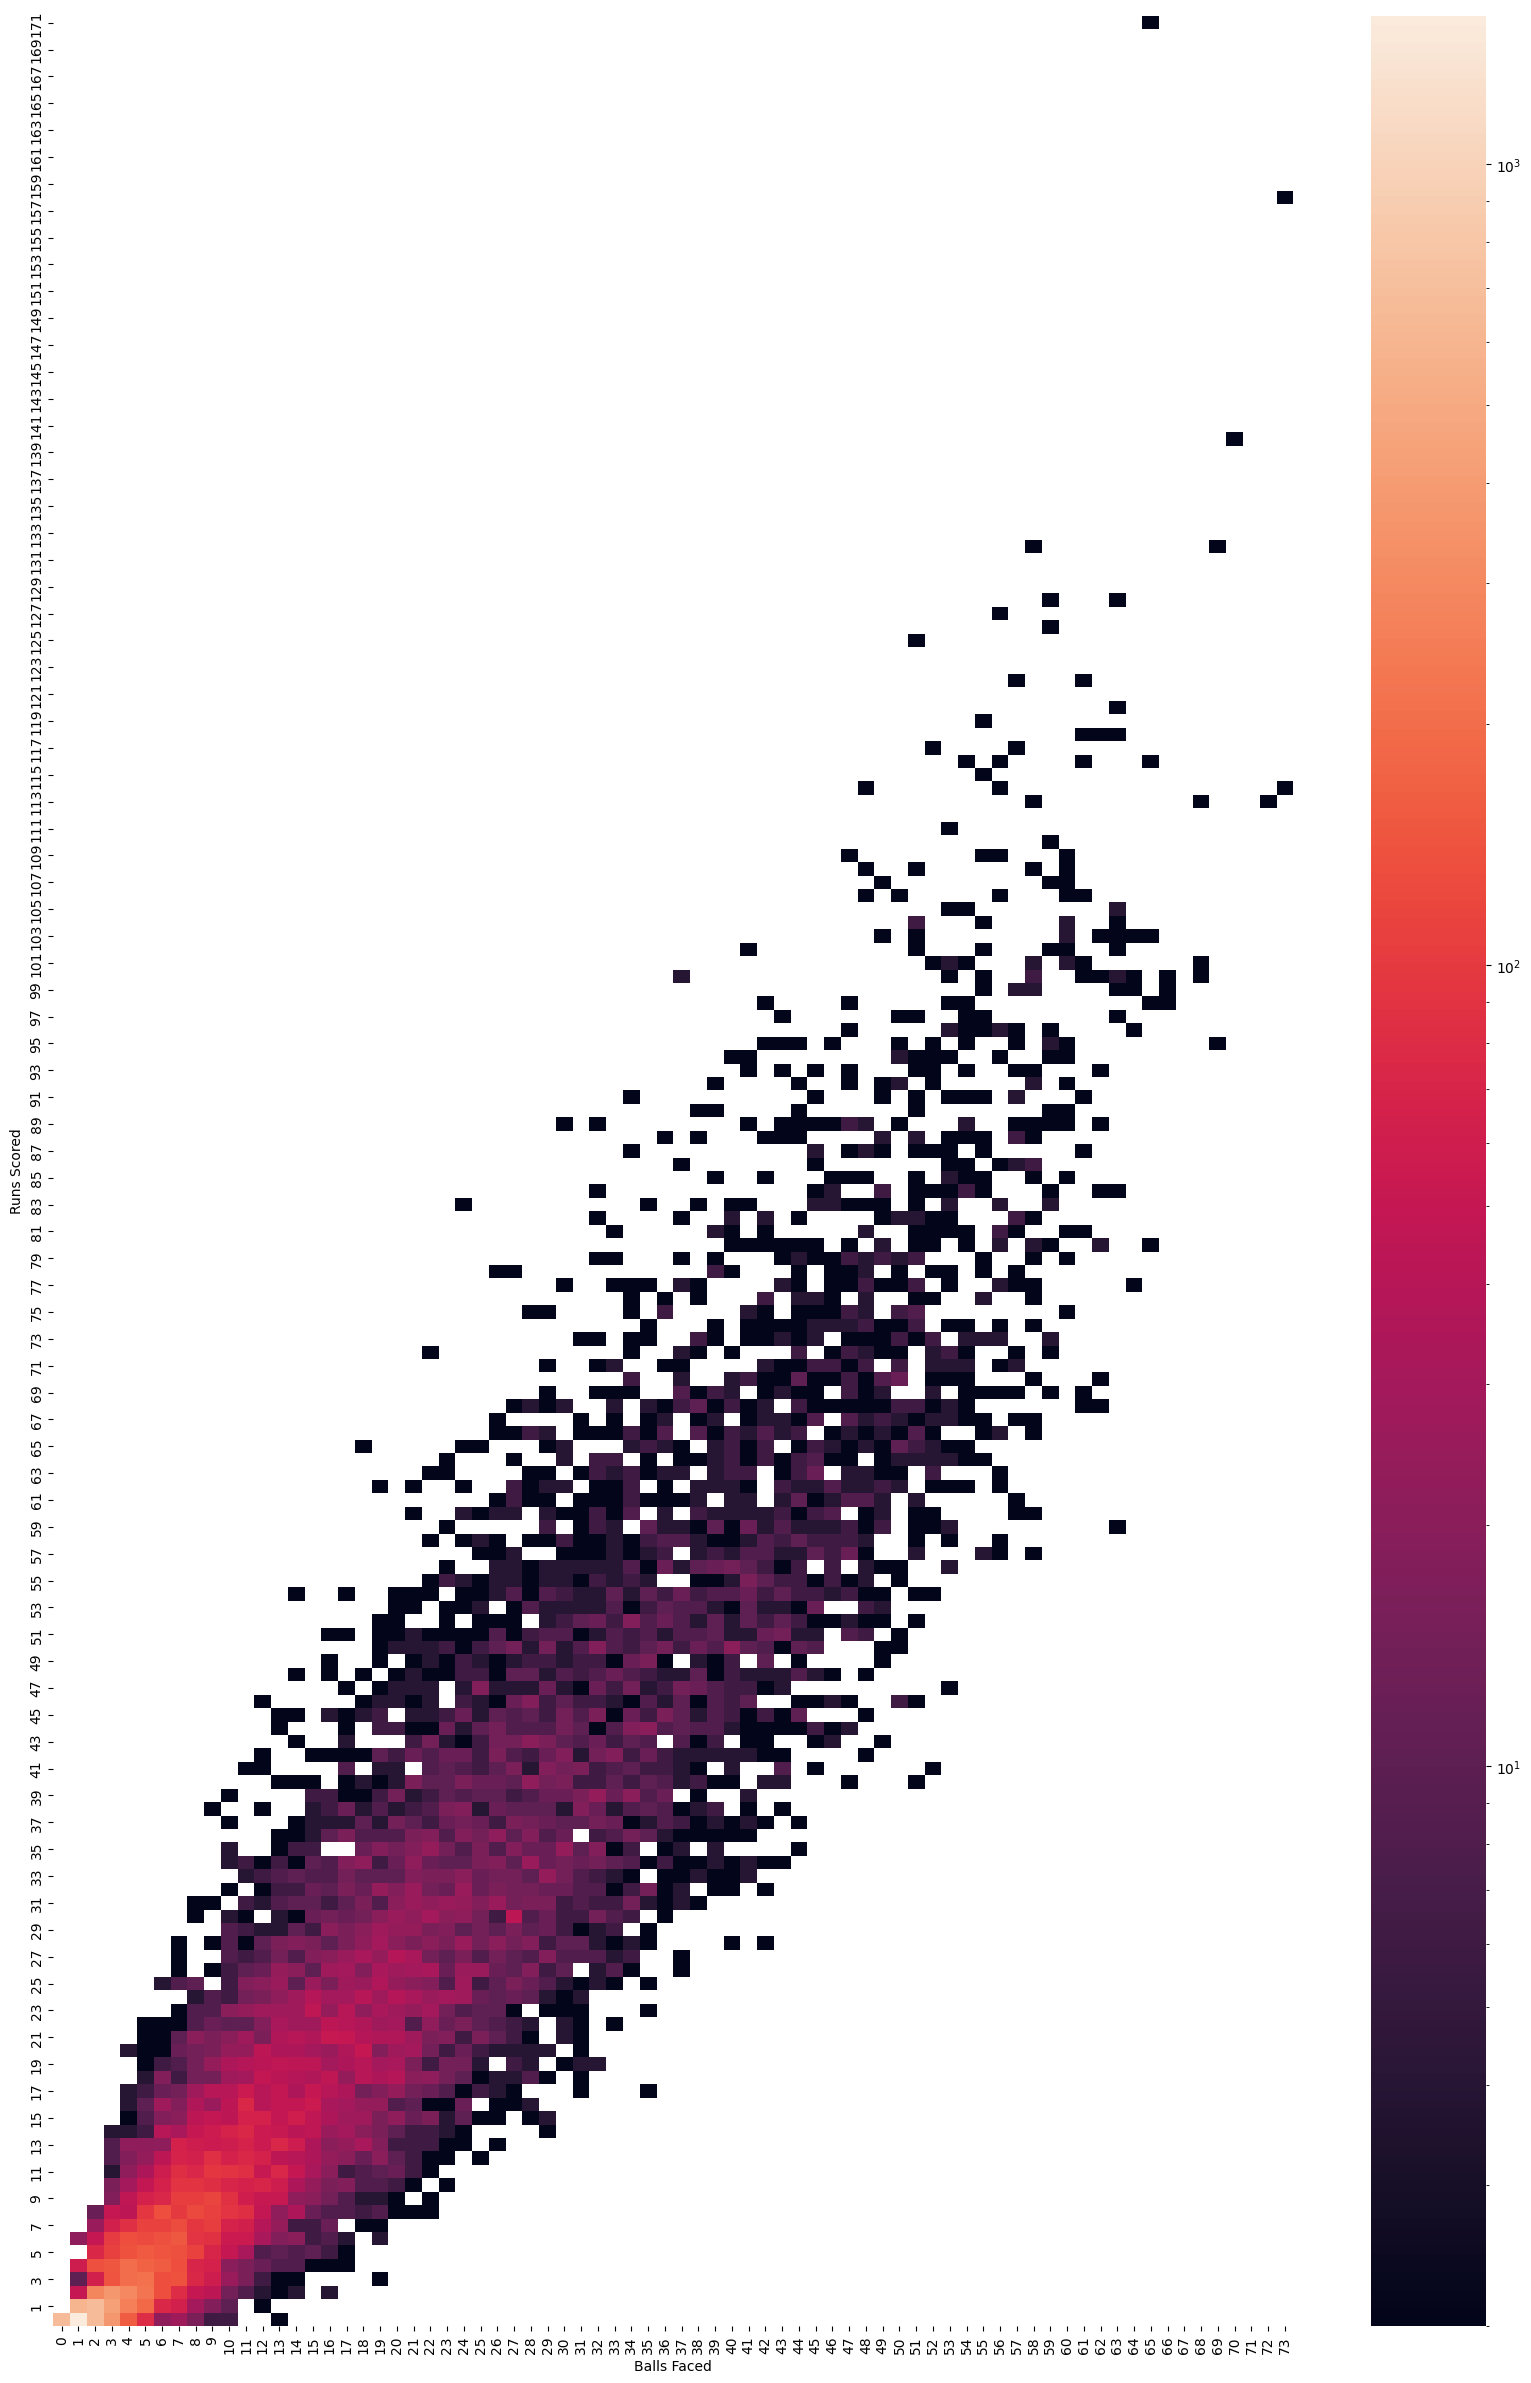

In [25]:
from seaborn import heatmap

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

frequency_table = pd.crosstab(every_bat_runs, every_bat_balls, colnames=['Balls Faced'], rownames=['Runs Scored'])

# Reindex the table to include all rows and columns, filling missing values with 0
frequency_table = frequency_table.reindex(index=range(max(every_bat_runs)+1), columns=range(max(every_bat_balls)+1), fill_value=0)

plt.figure(figsize=(20,30))

heatmap(frequency_table.iloc[::-1], norm=LogNorm())

frequency_table